In [ ]:
# ==========================================================
# PROJECT:
# AI Strategic Intelligence
# STEP 6 - NLP using BERT (Transformers)
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from google.colab import files

print("="*60)
print("Libraries loaded successfully")
print("="*60)

Libraries loaded successfully


In [ ]:
# ==========================================================
# Install Hugging Face Transformers
# ==========================================================

!pip -q install transformers torch accelerate

In [ ]:
# ==========================================================
# Load processed dataset
# ==========================================================

uploaded = files.upload()

Saving processed_scopus.csv to processed_scopus.csv


In [ ]:
# ==========================================================
# Read dataset
# ==========================================================

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("="*60)
print("Dataset loaded successfully")
print("="*60)

print(f"\nDocuments: {len(df)}")

display(df[['Title','Year','Abstract']].head())

Dataset loaded successfully

Documents: 483


,Title,Year,Abstract
0,Toward a continuous learning educational model...,2025,The rapidly evolving and technology-driven lab...
1,Addressing digital competence gaps in vocation...,2025,Purpose – To investigate how VET teachers in p...
2,Modelling the impact of Artificial Intelligenc...,2021,This article describes an original model devel...
3,ENHANCING NON-FORMAL LEARNING CERTIFICATE CLAS...,2025,Aim/Purpose The purpose of this paper is to ad...
4,Crowdsourcing in Kazakhstan's higher education...,2025,The rapid transformation of professional compe...


In [ ]:
# ==========================================================
# Prepare abstracts for sentiment analysis
# ==========================================================

# Keep only the first 512 characters
df["text"] = (
    df["Abstract"]
    .fillna("")
    .astype(str)
    .str[:512]
)

print("="*60)
print("Texts prepared successfully")
print("="*60)

print(f"\nDocuments ready: {len(df)}")

print("\nExample:\n")
print(df["text"].iloc[0][:500])

Texts prepared successfully

Documents ready: 483

Example:

The rapidly evolving and technology-driven labor market underscores the need for continuous education and lifelong learning to ensure individuals remain adaptable and professionally relevant. It demands institutions that effectively bridge the gap between education and the workforce by promptly and pertinently modifying its programs and curricula, led by educators who are highly experts in specific skills and knowledge, as well as with pedagogical knowledge. In this address, robust educational m


In [ ]:
# ==========================================================
# Load Transformer model
# ==========================================================

from transformers import pipeline

sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

print("="*60)
print("Transformer model loaded successfully")
print("="*60)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  501MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

model.safetensors: downloading bytes:           |  0.00B            

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Transformer model loaded successfully


In [ ]:
# ==========================================================
# Sentiment classification
# ==========================================================

from tqdm import tqdm

tqdm.pandas()

results = []

print("="*60)
print("Starting sentiment analysis...")
print("="*60)

for text in tqdm(df["text"]):

    prediction = sentiment_pipeline(text)[0]

    results.append({
        "label": prediction["label"],
        "score": prediction["score"]
    })

print("\nAnalysis completed successfully.")

Starting sentiment analysis...


100%|██████████| 483/483 [03:10<00:00,  2.54it/s]


Analysis completed successfully.


In [ ]:
# ==========================================================
# Build sentiment dataframe
# ==========================================================

sentiment_df = pd.DataFrame(results)

df["Sentiment"] = sentiment_df["label"]

df["Confidence"] = sentiment_df["score"]

print("="*60)
print("Sentiment dataset created successfully")
print("="*60)

display(
    df[
        [
            "Year",
            "Title",
            "Sentiment",
            "Confidence"
        ]
    ].head()
)

Sentiment dataset created successfully


,Year,Title,Sentiment,Confidence
0,2025,Toward a continuous learning educational model...,neutral,0.645368
1,2025,Addressing digital competence gaps in vocation...,neutral,0.879634
2,2021,Modelling the impact of Artificial Intelligenc...,neutral,0.918147
3,2025,ENHANCING NON-FORMAL LEARNING CERTIFICATE CLAS...,neutral,0.751028
4,2025,Crowdsourcing in Kazakhstan's higher education...,neutral,0.696430


In [ ]:
# ==========================================================
# Sentiment distribution
# ==========================================================

print("="*60)
print("Sentiment distribution")
print("="*60)

print(df["Sentiment"].value_counts())

print("\nPercentages")

print(
    round(
        df["Sentiment"]
        .value_counts(normalize=True)*100,
        2
    )
)

Sentiment distribution
Sentiment
neutral     343
positive    123
negative     17
Name: count, dtype: int64

Percentages
Sentiment
neutral     71.01
positive    25.47
negative     3.52
Name: proportion, dtype: float64


In [ ]:
# ==========================================================
# Numerical sentiment score
# ==========================================================

mapping = {
    "negative":-1,
    "neutral":0,
    "positive":1,
    "LABEL_0":-1,
    "LABEL_1":0,
    "LABEL_2":1
}

df["SentimentScore"] = df["Sentiment"].map(mapping)

annual_sentiment = (
    df
    .groupby("Year")["SentimentScore"]
    .mean()
    .reset_index()
)

display(annual_sentiment)

,Year,SentimentScore
0,2018,0.000000
1,2019,0.500000
2,2020,0.200000
3,2021,0.045455
4,2022,0.148148
5,2023,0.297297
6,2024,0.328767
7,2025,0.243750
8,2026,0.143885


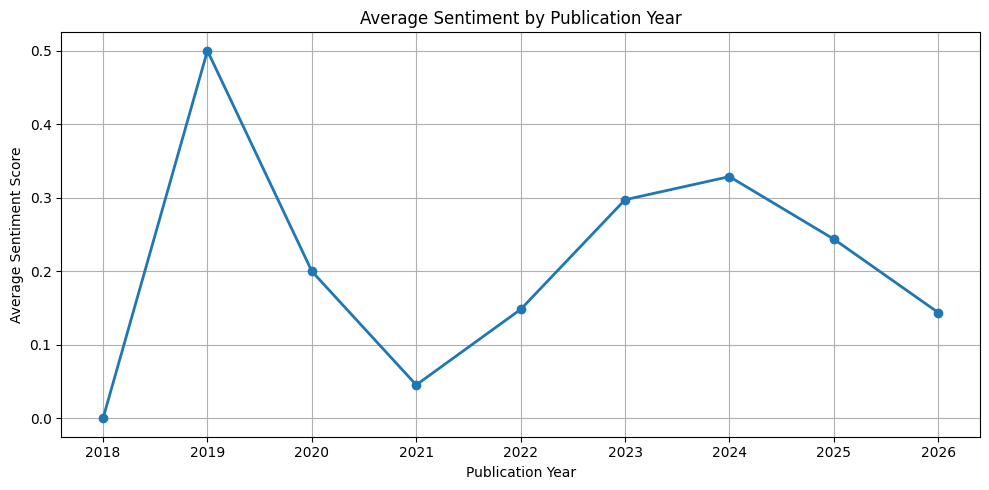

In [ ]:
# ============================================================
# CELL 11
# Sentiment evolution by publication year
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    annual_sentiment["Year"],
    annual_sentiment["SentimentScore"],
    marker="o",
    linewidth=2
)

plt.title("Average Sentiment by Publication Year")

plt.xlabel("Publication Year")

plt.ylabel("Average Sentiment Score")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "sentiment_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# CELL 12
# Save NLP results
# ============================================================

df.to_csv(
    "processed_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)

annual_sentiment.to_csv(
    "annual_sentiment.csv",
    index=False,
    encoding="utf-8-sig"
)

print("="*60)
print("NLP outputs exported successfully")
print("="*60)

print("\nGenerated files:")
print("- processed_sentiment.csv")
print("- annual_sentiment.csv")
print("- sentiment_evolution.png")

NLP outputs exported successfully

Generated files:
- processed_sentiment.csv
- annual_sentiment.csv
- sentiment_evolution.png
